# DATA 612 Project 4: Accuracy and Beyond
### Aaliyah John-Harry


## Project Objective

The goal of this project is to compare multiple recommender algorithms, add a user-experience adjustment, and then measure how accuracy changes before and after that adjustment. For Project 4, I am using the **HetRec 2011 Last.fm 2K dataset** instead of the MovieLens dataset from my earlier projects. I will be working on a music recommendation system: given artists a user has already listened to, recommend additional artists they may like.

## Dataset

The **HetRec 2011 Last.fm 2K dataset** contains music listening behavior from Last.fm users. Each row represents a user–artist interaction, where the weight is the total number of times that user listened to the artist. 

Because this dataset is based on listening behavior rather than explicit 1–5 star ratings, I inferred the user's preferences from these listening counts(higher weights = stronger interest in an artist).

In [1]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

RANDOM_STATE = 275
np.random.seed(RANDOM_STATE)

In [2]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

url = 'https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip'
zip_path = DATA_DIR / 'hetrec2011-lastfm-2k.zip'
extract_dir = DATA_DIR / 'hetrec2011-lastfm-2k'

if not zip_path.exists():
    print('Downloading Last.fm dataset...')
    urllib.request.urlretrieve(url, zip_path)

if not extract_dir.exists():
    print('Extracting dataset...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)

print('Files:')
for file in sorted(extract_dir.iterdir()):
    print(file.name)

Extracting dataset...
Files:
artists.dat
readme.txt
tags.dat
user_artists.dat
user_friends.dat
user_taggedartists-timestamps.dat
user_taggedartists.dat


In [3]:
artists = pd.read_csv(extract_dir / 'artists.dat', sep='	', encoding='latin-1')
user_artists = pd.read_csv(extract_dir / 'user_artists.dat', sep='	')
user_taggedartists = pd.read_csv(extract_dir / 'user_taggedartists.dat', sep='	')
tags = pd.read_csv(extract_dir / 'tags.dat', sep='	', encoding='latin-1')

print('artists:', artists.shape)
print('user_artists:', user_artists.shape)
print('user_taggedartists:', user_taggedartists.shape)
print('tags:', tags.shape)

user_artists.head()

artists: (17632, 4)
user_artists: (92834, 3)
user_taggedartists: (186479, 6)
tags: (11946, 2)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


## Data Preparation

In this dataset, the listening weights ranged from just a few plays to well over 10,000. Because of that, I applied a log transformation to reduce the influence of the extremely large values while still preserving differences in user preference. This allowed me to recognize that users who listen to an artist hundreds or thousands of times have a stronger preference than users who only listened once, without allowing a few very large play counts to dominate the model.

Since there are no ratings to predict in this dataset, I shifted the goal from estimating an exact score to just identifying what artists a user is most likely to enjoy next. So it made more sense to evaluate the recommender using top-N ranking metrics like Precision@10, Recall@10, and NDCG@10, all of which measure how well the system ranks relevant recommendations rather than how accurately it predicts numerical ratings.

In [14]:
interactions = user_artists.rename(columns={'artistID':'artistId'}).copy()

interactions['weight'] = np.log1p(interactions['weight'])

interactions = interactions[['userID','artistId','weight']] 
interactions.head()

,userID,artistId,weight
0,2,51,9.538492
1,2,52,9.366575
2,2,53,9.337149
3,2,54,9.239996
4,2,55,9.103200


In [15]:
n_users = interactions['userID'].nunique()
n_artists = interactions['artistId'].nunique()
n_observed_pairs = len(interactions)

sparsity = 1 - (n_observed_pairs / (n_users * n_artists))

summary = pd.DataFrame({
    'Metric': ['Users', 'Artists', 'Observed user-artist pairs', 'Sparsity'],
    'Value': [n_users, n_artists, n_observed_pairs, round(sparsity, 4)]
})

summary

,Metric,Value
0,Users,1892.0000
1,Artists,17632.0000
2,Observed user-artist pairs,92834.0000
3,Sparsity,0.9972


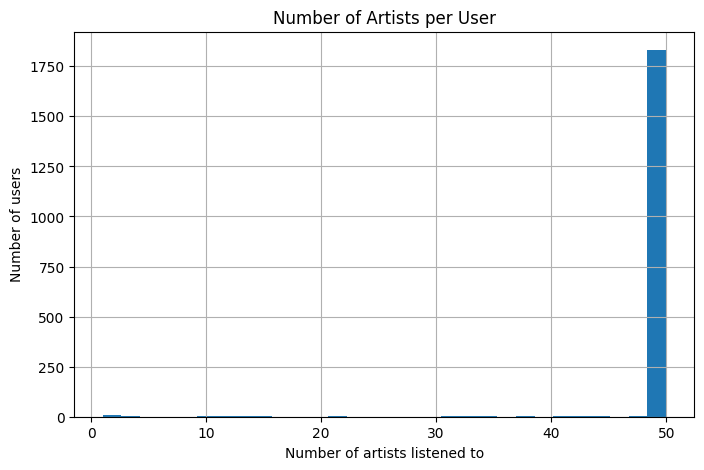

In [16]:
plt.figure(figsize=(8, 5))
interactions.groupby('userID')['artistId'].count().hist(bins=30)
plt.title('Number of Artists per User')
plt.xlabel('Number of artists listened to')
plt.ylabel('Number of users')
plt.show()

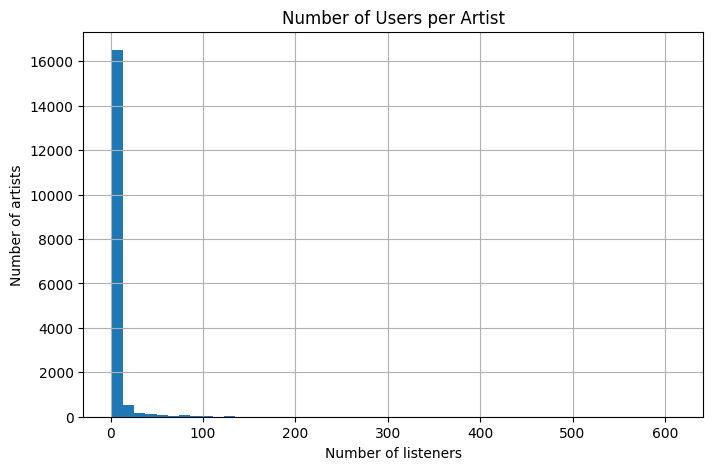

In [17]:
plt.figure(figsize=(8, 5))

interactions.groupby('artistId')['userID'].nunique().hist(bins=50)

plt.title('Number of Users per Artist')
plt.xlabel('Number of listeners')
plt.ylabel('Number of artists')

plt.show()

## Train/Test Split

To evaluate the models offline, I held out a portion of each eligible user’s artist interactions as test data. The training set contains the remaining user-artist pairs along with their log-transformed listening weights. 

This creates a situation where the system knows some of the artists a user listened to and tries to recommend additional artists that were hidden during evaluation.

In [18]:
def train_test_split_by_user(df, test_size=0.2, min_items=5, random_state=42):
    train_parts = []
    test_parts = []
    rng = np.random.default_rng(random_state)

    for user_id, group in df.groupby('userID'):
        if len(group) < min_items:
            train_parts.append(group)
            continue

        test_n = max(1, int(round(len(group) * test_size)))
        test_idx = rng.choice(group.index.to_numpy(), size=test_n, replace=False)
        test_mask = group.index.isin(test_idx)

        test_parts.append(group.loc[test_mask])
        train_parts.append(group.loc[~test_mask])

    train_df = pd.concat(train_parts).reset_index(drop=True)
    test_df = pd.concat(test_parts).reset_index(drop=True)
    return train_df, test_df

train_df, test_df = train_test_split_by_user(interactions, test_size=0.2, min_items=5, random_state=RANDOM_STATE)

print('Train interactions:', train_df.shape[0])
print('Test interactions:', test_df.shape[0])
print('Users in test:', test_df['userID'].nunique())

Train interactions: 74272
Test interactions: 18562
Users in test: 1877


In [19]:
user_ids = sorted(train_df['userID'].unique())
artist_ids = sorted(train_df['artistId'].unique())

user_to_idx = {u: i for i, u in enumerate(user_ids)}
artist_to_idx = {a: i for i, a in enumerate(artist_ids)}
idx_to_artist = {i: a for a, i in artist_to_idx.items()}

train_df = train_df[
    train_df['userID'].isin(user_to_idx) & 
    train_df['artistId'].isin(artist_to_idx)
].copy()

test_df = test_df[
    test_df['userID'].isin(user_to_idx) & 
    test_df['artistId'].isin(artist_to_idx)
].copy()

row = train_df['userID'].map(user_to_idx)
col = train_df['artistId'].map(artist_to_idx)

data = train_df['weight'].values

user_artist_matrix = csr_matrix(
    (data, (row, col)),
    shape=(len(user_ids), len(artist_ids))
)

user_artist_matrix.shape

(1892, 15361)

## Evaluation Metrics

Since this is a top-N recommendation problem, I use ranking metrics and beyond-accuracy metrics:

- **Precision@10:** Of the 10 recommended artists, how many were actually in the user's hidden test set?
- **Recall@10:** Of the artists hidden in the test set, how many did the recommender successfully recover?
- **NDCG@10:** Gives more credit when relevant artists appear closer to the top of the list.
- **Novelty@10:** Measures whether the recommender suggests less-popular artists instead of only recommending the most frequently listened-to artists.
- **Diversity@10:** Measures how different the recommended artists are from one another.
- **Serendipity@10 proxy:** Measures whether recommendations are different from the user's previous listening history while still being potentially relevant.

Because this evaluation uses offline historical data, serendipity is only an approximation. It estimates whether recommendations are both relevant and unexpected, but it cannot determine whether a user would actually find them pleasantly surprising in a real-world setting.


In [21]:
def precision_at_k(recs, relevant_items, k=10):
    recs_k = recs[:k]
    if len(recs_k) == 0:
        return np.nan
    return len(set(recs_k) & set(relevant_items)) / k


def recall_at_k(recs, relevant_items, k=10):
    if len(relevant_items) == 0:
        return np.nan
    recs_k = recs[:k]
    return len(set(recs_k) & set(relevant_items)) / len(set(relevant_items))


def ndcg_at_k(recs, relevant_items, k=10):
    relevant_set = set(relevant_items)
    dcg = 0.0
    for i, item in enumerate(recs[:k], start=1):
        if item in relevant_set:
            dcg += 1 / np.log2(i + 1)
    ideal_hits = min(len(relevant_set), k)
    idcg = sum(1 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else np.nan

## Artist Tag Features for Diversity and Serendipity

To measure diversity and serendipity, I use the user-generated tags in the dataset. 

Artists with similar tags are treated as more similar. A diverse list should avoid recommending artists that are all too similar to each other, while serendipity should include artists that are not too similar to what the user already listened to but are still relevant to their interests.

In [22]:
artist_tags = user_taggedartists.rename(columns={'artistID': 'artistId'}).copy()
artist_tags = artist_tags[artist_tags['artistId'].isin(artist_to_idx)]

# Keep the most common tags to make the tag matrix manageable.
top_tags = artist_tags['tagID'].value_counts().head(300).index
artist_tags = artist_tags[artist_tags['tagID'].isin(top_tags)]

artist_tag_counts = (
    artist_tags
    .groupby(['artistId', 'tagID'])
    .size()
    .reset_index(name='count')
)

artist_tag_matrix = artist_tag_counts.pivot(index='artistId', columns='tagID', values='count').fillna(0)
artist_tag_matrix = artist_tag_matrix.reindex(artist_ids).fillna(0)

artist_similarity = cosine_similarity(artist_tag_matrix)
artist_similarity = np.nan_to_num(artist_similarity)

artist_tag_matrix.shape

(15361, 300)

In [24]:
artist_popularity = train_df.groupby('artistId')['userID'].nunique().reindex(artist_ids).fillna(0)
max_popularity = artist_popularity.max()

artist_popularity_norm = (artist_popularity / max_popularity).to_dict()
artist_novelty = {artist: 1 - pop for artist, pop in artist_popularity_norm.items()}

user_train_items = train_df.groupby('userID')['artistId'].apply(set).to_dict()
user_test_items = test_df.groupby('userID')['artistId'].apply(set).to_dict()


def novelty_at_k(recs, k=10):
    recs_k = recs[:k]
    if len(recs_k) == 0:
        return np.nan
    return np.mean([artist_novelty.get(item, 0) for item in recs_k])


def diversity_at_k(recs, k=10):
    recs_k = [item for item in recs[:k] if item in artist_to_idx]
    if len(recs_k) < 2:
        return np.nan
    idxs = [artist_to_idx[item] for item in recs_k]
    pair_sims = []
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            pair_sims.append(artist_similarity[idxs[i], idxs[j]])
    return 1 - np.mean(pair_sims) if pair_sims else np.nan


def serendipity_at_k(user_id, recs, k=10, max_history=50):
    recs_k = [item for item in recs[:k] if item in artist_to_idx]
    history = [item for item in user_train_items.get(user_id, set()) if item in artist_to_idx]

    if len(recs_k) == 0 or len(history) == 0:
        return np.nan

    # Limit very large histories for speed and consistency.
    history = history[:max_history]
    history_idxs = [artist_to_idx[item] for item in history]

    scores = []
    for item in recs_k:
        item_idx = artist_to_idx[item]
        avg_sim_to_history = np.mean([artist_similarity[item_idx, h_idx] for h_idx in history_idxs])
        scores.append(1 - avg_sim_to_history)

    return np.mean(scores) if scores else np.nan

## Recommender Algorithm 1: Popularity Baseline

The first model recommends the most popular artists based on the number of unique users who listened to each artist in the training data. This is not personalized, but it is a useful benchmark because popular artists often perform reasonably well in recommender systems.

This answers: *What would we recommend if we only knew what artists were popular overall?*

In [25]:
popular_artists = (
    train_df.groupby('artistId')['userID']
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)


def recommend_popularity(user_id, n=50):
    seen = user_train_items.get(user_id, set())
    return [artist for artist in popular_artists if artist not in seen][:n]

## Recommender Algorithm 2: Item-Item Collaborative Filtering

I designed this item-item collaborative filtering algorithm to recommend artists who are similar to artists the user has already listened to.

Unlike the popularity baseline in the algorithm above, this one is personalized because each user's recommendation list is based on their own listening history. Since I built the interaction matrix using log-transformed listening weights, artists that a user listened to more frequently contribute more strongly to the similarity calculations.

In [29]:
item_similarity = cosine_similarity(user_artist_matrix.T)
item_similarity = np.nan_to_num(item_similarity)
np.fill_diagonal(item_similarity, 0)

item_similarity.shape

(15361, 15361)

In [30]:
def recommend_item_item_cf(user_id, n=50):
    if user_id not in user_to_idx:
        return recommend_popularity(user_id, n=n)

    user_idx = user_to_idx[user_id]
    user_vector = user_artist_matrix[user_idx]

    seen_indices = user_vector.indices
    seen_weights = user_vector.data

    if len(seen_indices) == 0:
        return recommend_popularity(user_id, n=n)

    scores = np.dot(seen_weights, item_similarity[seen_indices])

    # Do not recommend artists the user already listened to.
    scores[seen_indices] = -np.inf

    top_indices = np.argsort(scores)[::-1][:n]

    return [
        idx_to_artist[i]
        for i in top_indices
        if scores[i] > -np.inf
    ]

## Recommender Algorithm 3: User-User Collaborative Filtering

I designed this user-user collaborative filtering algorithm to find users with similar weighted listening histories and recommend artists that those similar users listened to.
Since I built the interaction matrix using log-transformed listening weights, users who listened heavily to similar artists should have a stronger influence than users with weaker listening behavior.

In [31]:
user_similarity = cosine_similarity(user_artist_matrix)
user_similarity = np.nan_to_num(user_similarity)
np.fill_diagonal(user_similarity, 0)

user_similarity.shape

(1892, 1892)

In [32]:
def recommend_user_user_cf(user_id, n=50, k_neighbors=30):
    if user_id not in user_to_idx:
        return recommend_popularity(user_id, n=n)

    user_idx = user_to_idx[user_id]
    seen_indices = set(user_artist_matrix[user_idx].indices)

    neighbor_idx = np.argsort(user_similarity[user_idx])[::-1][:k_neighbors]
    neighbor_scores = user_similarity[user_idx, neighbor_idx]

    scores = np.asarray(
        neighbor_scores @ user_artist_matrix[neighbor_idx]
    ).ravel()

    # Do not recommend artists the user already listened to.
    if seen_indices:
        scores[list(seen_indices)] = -np.inf

    top_indices = np.argsort(scores)[::-1][:n]

    return [
        idx_to_artist[i]
        for i in top_indices
        if scores[i] > -np.inf
    ]

## Evaluation Helper

- This function evaluates a recommender on the same users and the same metrics each time.
- Keeping the evaluation process consistent makes the model comparison fair, since each algorithm is judged on the same hidden test items and the same top-10 recommendation length.

In [33]:
def evaluate_recommender(recommender_func, users, k=10):
    rows = []
    for user_id in users:
        relevant = user_test_items.get(user_id, set())
        if len(relevant) == 0:
            continue

        recs = recommender_func(user_id, n=max(50, k))
        rows.append({
            'userID': user_id,
            'precision_at_10': precision_at_k(recs, relevant, k),
            'recall_at_10': recall_at_k(recs, relevant, k),
            'ndcg_at_10': ndcg_at_k(recs, relevant, k),
            'novelty_at_10': novelty_at_k(recs, k),
            'diversity_at_10': diversity_at_k(recs, k),
            'serendipity_at_10': serendipity_at_k(user_id, recs, k)
        })
    return pd.DataFrame(rows)


def summarize_eval(eval_df, model_name):
    metric_cols = [
        'precision_at_10', 'recall_at_10', 'ndcg_at_10',
        'novelty_at_10', 'diversity_at_10', 'serendipity_at_10'
    ]
    summary = eval_df[metric_cols].mean().to_dict()
    summary['model'] = model_name
    return summary


eval_users = sorted(set(test_df['userID']) & set(train_df['userID']))
len(eval_users)

1874

## Parameter Tuning for User-User CF

- To select the best neighborhood size for the user-user collaborative filtering model, I tested several neighborhood sizes for user-user collaborative filtering (k=10, 20, 30, and 50).
- The first graph compares the accuracy metrics across the different neighborhood sizes. While the differences were relatively small, k=30 produced the highest NDCG@10, so I selected it for the final model because NDCG rewards both recommendation relevance and ranking position.
- The accuracy metrics remained fairly consistent across all neighborhood sizes, suggesting that the user-user collaborative filtering model is relatively stable and not overly sensitive to the neighborhood size.
- Looking beyond accuracy in the second graph, novelty and diversity decreased slightly as the neighborhood size increased, while serendipity remained nearly unchanged.

Overall, these results indicate that changing the neighborhood size had only a small impact on the characteristics of the recommendations beyond accuracy.

In [34]:
k_values = [10, 20, 30, 50]
tuning_rows = []

for k_neighbors in k_values:
    func = lambda user_id, n=50, k_neighbors=k_neighbors: recommend_user_user_cf(
        user_id, n=n, k_neighbors=k_neighbors
    )
    eval_df = evaluate_recommender(func, eval_users, k=10)
    row = summarize_eval(eval_df, f'User-User CF k={k_neighbors}')
    row['k_neighbors'] = k_neighbors
    tuning_rows.append(row)

user_user_tuning = pd.DataFrame(tuning_rows).sort_values('ndcg_at_10', ascending=False)
best_k = int(user_user_tuning.iloc[0]['k_neighbors'])

print('Best k_neighbors based on NDCG@10:', best_k)
user_user_tuning

Best k_neighbors based on NDCG@10: 30


,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10,model,k_neighbors
2,0.169904,0.189746,0.221579,0.621817,0.480197,0.680545,User-User CF k=30,30
1,0.170064,0.189640,0.220358,0.640863,0.487162,0.679454,User-User CF k=20,20
3,0.168463,0.187506,0.219369,0.597684,0.473949,0.683472,User-User CF k=50,50
0,0.163340,0.182694,0.211902,0.676665,0.509933,0.682902,User-User CF k=10,10


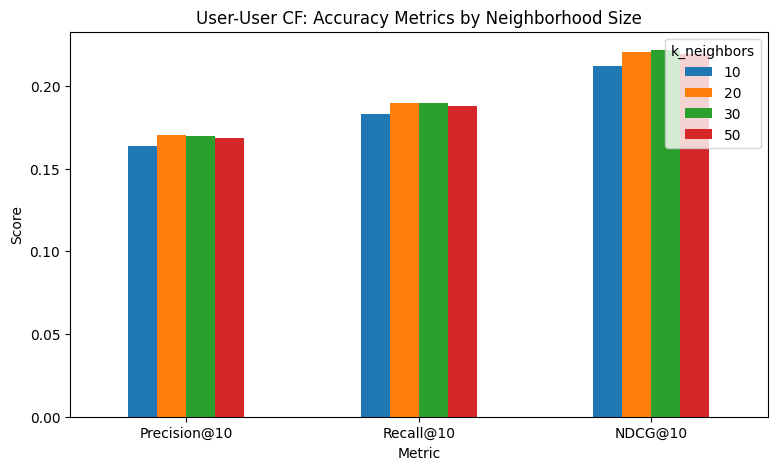

In [43]:
metric_cols = [
    'precision_at_10',
    'recall_at_10',
    'ndcg_at_10'
]

plot_df = user_user_tuning.sort_values('k_neighbors')

plot_data = (
    plot_df
    .set_index('k_neighbors')[metric_cols]
    .T
)

plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9, 5))

plt.title('User-User CF: Accuracy Metrics by Neighborhood Size')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='k_neighbors')
plt.show()

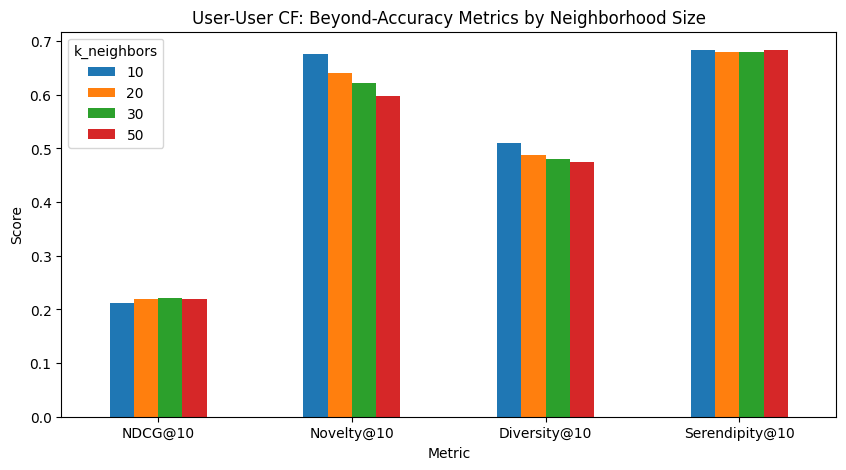

In [44]:
metric_cols = [
    'ndcg_at_10',
    'novelty_at_10',
    'diversity_at_10',
    'serendipity_at_10'
]

plot_df = user_user_tuning.sort_values('k_neighbors')

plot_data = (
    plot_df
    .set_index('k_neighbors')[metric_cols]
    .T
)

plot_data.index = ['NDCG@10', 'Novelty@10', 'Diversity@10', 'Serendipity@10']

plot_data.plot(kind='bar', figsize=(10, 5))

plt.title('User-User CF: Beyond-Accuracy Metrics by Neighborhood Size')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='k_neighbors')
plt.show()

## Offline Evaluation Before Discovery Re-Ranking

Before applying any re-ranking, I evaluated each recommender using both accuracy and beyond-accuracy metrics to establish a baseline for comparison.

- Among the three models, Item-Item Collaborative Filtering achieved the strongest overall ranking performance, producing the highest Precision@10, Recall@10, and NDCG@10.
- The User-User CF model performed similarly but ranked slightly lower across the accuracy metrics.
- As expected, the Popularity Baseline produced the weakest accuracy results because it recommends the same popular artists to every user without considering individual listening history.
- Looking beyond accuracy, the Popularity Baseline achieved the highest Diversity@10 and Serendipity@10 according to the offline proxy metrics, while the collaborative filtering models produced substantially higher Novelty@10.
- This shows that strong ranking accuracy does not always correspond to the highest scores on every beyond-accuracy metric, reinforcing the importance of evaluating recommender systems from multiple perspectives.

In [45]:
models = {
    'Popularity Baseline': recommend_popularity,
    'Item-Item CF': recommend_item_item_cf,
    f'User-User CF (k={best_k})': lambda user_id, n=50: recommend_user_user_cf(user_id, n=n, k_neighbors=best_k)
}

results_before = []
raw_eval_frames = {}

for name, func in models.items():
    eval_df = evaluate_recommender(func, eval_users, k=10)
    raw_eval_frames[name] = eval_df
    results_before.append(summarize_eval(eval_df, name))

results_before = pd.DataFrame(results_before)
results_before = results_before[['model', 'precision_at_10', 'recall_at_10', 'ndcg_at_10', 'novelty_at_10', 'diversity_at_10', 'serendipity_at_10']]
results_before

,model,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10
0,Popularity Baseline,0.066596,0.072355,0.080221,0.290698,0.513963,0.821921
1,Item-Item CF,0.177535,0.197868,0.232676,0.675820,0.503893,0.680855
2,User-User CF (k=30),0.169904,0.189746,0.221579,0.621817,0.480197,0.680545


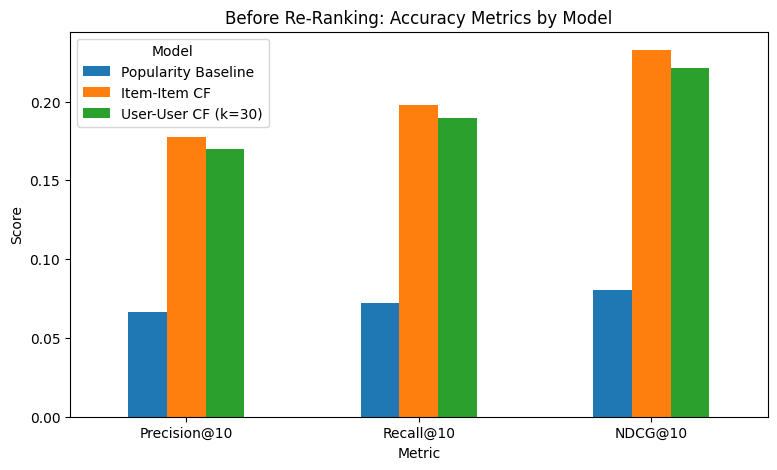

In [48]:
metric_cols = ['precision_at_10', 'recall_at_10', 'ndcg_at_10']

plot_data = results_before.set_index('model')[metric_cols].T
plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9, 5))

plt.title('Before Re-Ranking: Accuracy Metrics by Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

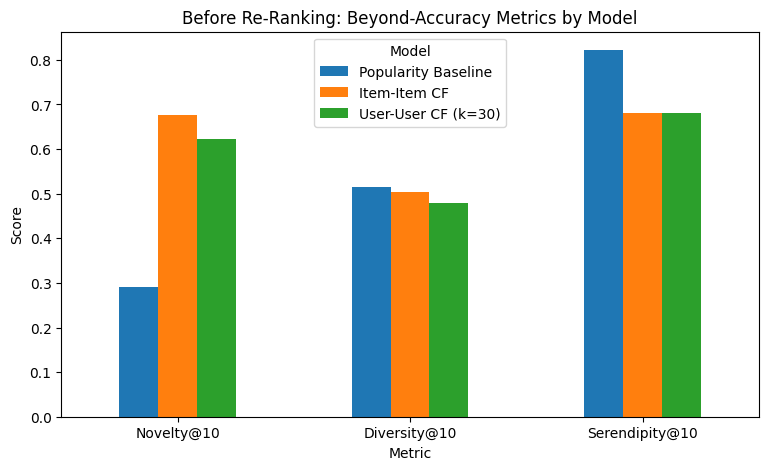

In [49]:
metric_cols = ['novelty_at_10', 'diversity_at_10', 'serendipity_at_10']

plot_data = results_before.set_index('model')[metric_cols].T
plot_data.index = ['Novelty@10', 'Diversity@10', 'Serendipity@10']

plot_data.plot(kind='bar', figsize=(9, 5))

plt.title('Before Re-Ranking: Beyond-Accuracy Metrics by Model')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

## Supporting Business and User Experience Goals

One limitation of optimizing only for ranking accuracy is that recommenders can repeatedly suggest the same types of artists or the most popular content. From a user experience perspective, this can reduce discovery and make recommendations feel repetitive.

To address this, I implemented a discovery re-ranking step that balances the original recommendation score with three additional objectives:

- Novelty- encourages recommending less popular artists.
- Diversity- encourages recommending artists who are different from one another.
- Serendipity- encourages recommending artists that are different from the user's previous listening history while still being potentially relevant.


## Discovery Re-Ranking

I added a post-processing step that re-ranks each model's candidate list, building a new top-10 list by balancing:

- the original rank from the recommender
- novelty (based on inverse popularity)
- diversity (based on dissimilarity to already selected recommendations)
- serendipity (based on dissimilarity from the user's previous listening history)

In [69]:
def item_serendipity_score(user_id, item, max_history=50):
    if item not in artist_to_idx:
        return 0

    history = [
        h for h in user_train_items.get(user_id, set())
        if h in artist_to_idx
    ]

    if len(history) == 0:
        return 0

    history = history[:max_history]

    item_idx = artist_to_idx[item]
    history_idxs = [artist_to_idx[h] for h in history]

    avg_sim = np.mean([
        artist_similarity[item_idx, h_idx]
        for h_idx in history_idxs
    ])

    return 1 - avg_sim


def normalize_scores(score_dict):
    values = np.array(list(score_dict.values()))

    min_val = values.min()
    max_val = values.max()
    score_range = max_val - min_val if max_val > min_val else 1

    return {
        item: (score - min_val) / score_range
        for item, score in score_dict.items()
    }


def rerank_for_discovery(
    user_id,
    candidate_recs,
    k=10,
    relevance_weight=0.70,
    novelty_weight=0.10,
    diversity_weight=0.10,
    serendipity_weight=0.10
):
    if len(candidate_recs) <= k:
        return candidate_recs

    max_rank = len(candidate_recs)

    base_scores = {
        item: (max_rank - rank) / max_rank
        for rank, item in enumerate(candidate_recs)
    }

    novelty_raw = {
        item: artist_novelty.get(item, 0)
        for item in candidate_recs
    }

    serendipity_raw = {
        item: item_serendipity_score(user_id, item)
        for item in candidate_recs
    }

    base_scores = normalize_scores(base_scores)
    novelty_scores = normalize_scores(novelty_raw)
    serendipity_scores = normalize_scores(serendipity_raw)

    selected = []
    remaining = candidate_recs.copy()

    while len(selected) < k and remaining:
        best_item = None
        best_score = -np.inf

        for item in remaining:
            base = base_scores.get(item, 0)
            novelty = novelty_scores.get(item, 0)
            serendipity = serendipity_scores.get(item, 0)

            if selected and item in artist_to_idx:
                item_idx = artist_to_idx[item]
                selected_idxs = [
                    artist_to_idx[s]
                    for s in selected
                    if s in artist_to_idx
                ]

                if selected_idxs:
                    avg_similarity = np.mean([
                        artist_similarity[item_idx, s_idx]
                        for s_idx in selected_idxs
                    ])
                else:
                    avg_similarity = 0
            else:
                avg_similarity = 0

            diversity_bonus = 1 - avg_similarity

            score = (
                relevance_weight * base
                + novelty_weight * novelty
                + diversity_weight * diversity_bonus
                + serendipity_weight * serendipity
            )

            if score > best_score:
                best_score = score
                best_item = item

        selected.append(best_item)
        remaining.remove(best_item)

    return selected

In [70]:
def make_reranked_recommender(
    base_recommender,
    candidate_n=100,
    k=10,
    relevance_weight=0.70,
    novelty_weight=0.10,
    diversity_weight=0.10,
    serendipity_weight=0.10
):
    def recommender(user_id, n=50):
        candidates = base_recommender(user_id, n=candidate_n)

        reranked_top = rerank_for_discovery(
            user_id,
            candidates,
            k=k,
            relevance_weight=relevance_weight,
            novelty_weight=novelty_weight,
            diversity_weight=diversity_weight,
            serendipity_weight=serendipity_weight
        )

        remaining = [
            item for item in candidates
            if item not in reranked_top
        ]

        return reranked_top + remaining

    return recommender

reranked_models = {
    f'{name} + Discovery Re-Rank': make_reranked_recommender(func)
    for name, func in models.items()
}

## Offline Evaluation After Discovery Re-Ranking

- After applying the discovery re-ranking step, all three recommenders showed the expected trade-off between ranking accuracy and recommendation quality beyond accuracy.
    - Precision@10, Recall@10, and NDCG@10 decreased slightly because the re-ranker intentionally promotes artists that are less popular and more diverse instead of strictly preserving the original ranking.
    - In return, Novelty@10, Diversity@10, and Serendipity@10 improved for every model. The collaborative filtering approaches experienced the largest improvements in novelty and diversity, while the Popularity Baseline showed the greatest increase in serendipity, indicating that the recommendations became more exploratory while still maintaining reasonable ranking performance.

Overall, the Item-Item Collaborative Filtering model continued to achieve the strongest balance between ranking accuracy and discovery-oriented recommendation quality after re-ranking.

In [71]:
results_after = []
reranked_eval_frames = {}

for name, func in reranked_models.items():
    eval_df = evaluate_recommender(func, eval_users, k=10)
    reranked_eval_frames[name] = eval_df
    results_after.append(summarize_eval(eval_df, name))

results_after = pd.DataFrame(results_after)
results_after = results_after[['model', 'precision_at_10', 'recall_at_10', 'ndcg_at_10', 'novelty_at_10', 'diversity_at_10', 'serendipity_at_10']]
results_after

,model,precision_at_10,recall_at_10,ndcg_at_10,novelty_at_10,diversity_at_10,serendipity_at_10
0,Popularity Baseline + Discovery Re-Rank,0.026894,0.029278,0.026048,0.328688,0.545920,0.872302
1,Item-Item CF + Discovery Re-Rank,0.147705,0.162823,0.163698,0.740831,0.641715,0.728071
2,User-User CF (k=30) + Discovery Re-Rank,0.140822,0.156700,0.153024,0.692907,0.611378,0.721162


In [72]:
comparison_rows = []
metrics = ['precision_at_10', 'recall_at_10', 'ndcg_at_10', 'novelty_at_10', 'diversity_at_10', 'serendipity_at_10']

for base_name in models.keys():
    before = results_before[results_before['model'] == base_name].iloc[0]
    after_name = f'{base_name} + Discovery Re-Rank'
    after = results_after[results_after['model'] == after_name].iloc[0]

    for metric in metrics:
        comparison_rows.append({
            'model': base_name,
            'metric': metric,
            'before': before[metric],
            'after': after[metric],
            'change': after[metric] - before[metric]
        })

comparison = pd.DataFrame(comparison_rows)
comparison

,model,metric,before,after,change
0,Popularity Baseline,precision_at_10,0.066596,0.026894,-0.039701
1,Popularity Baseline,recall_at_10,0.072355,0.029278,-0.043076
2,Popularity Baseline,ndcg_at_10,0.080221,0.026048,-0.054173
3,Popularity Baseline,novelty_at_10,0.290698,0.328688,0.037990
4,Popularity Baseline,diversity_at_10,0.513963,0.545920,0.031958
5,Popularity Baseline,serendipity_at_10,0.821921,0.872302,0.050381
6,Item-Item CF,precision_at_10,0.177535,0.147705,-0.029829
7,Item-Item CF,recall_at_10,0.197868,0.162823,-0.035045
8,Item-Item CF,ndcg_at_10,0.232676,0.163698,-0.068978
9,Item-Item CF,novelty_at_10,0.675820,0.740831,0.065011


In [73]:
pivot_comparison = comparison.pivot(index='model', columns='metric', values='change')
pivot_comparison

metric,diversity_at_10,ndcg_at_10,novelty_at_10,precision_at_10,recall_at_10,serendipity_at_10
model,,,,,,
Item-Item CF,0.137822,-0.068978,0.065011,-0.029829,-0.035045,0.047215
Popularity Baseline,0.031958,-0.054173,0.037990,-0.039701,-0.043076,0.050381
User-User CF (k=30),0.131181,-0.068555,0.071090,-0.029082,-0.033046,0.040617


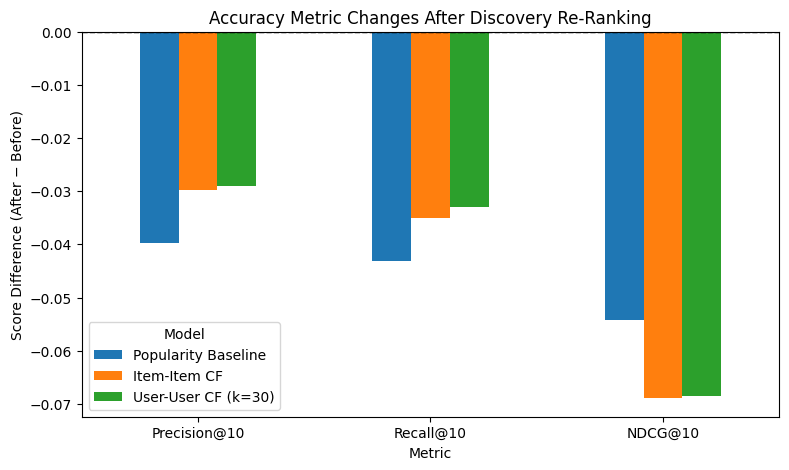

In [81]:
metric_cols = ['precision_at_10', 'recall_at_10', 'ndcg_at_10']

plot_data = (
    comparison[comparison['metric'].isin(metric_cols)]
    .pivot(index='metric', columns='model', values='change')
)

plot_data = plot_data[
    [
        'Popularity Baseline',
        'Item-Item CF',
        'User-User CF (k=30)'
    ]
]

plot_data = plot_data.loc[
    ['precision_at_10', 'recall_at_10', 'ndcg_at_10']
]

plot_data.index = ['Precision@10', 'Recall@10', 'NDCG@10']

plot_data.plot(kind='bar', figsize=(9,5))

plt.title('Accuracy Metric Changes After Discovery Re-Ranking')
plt.xlabel('Metric')
plt.ylabel('Score Difference (After − Before)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

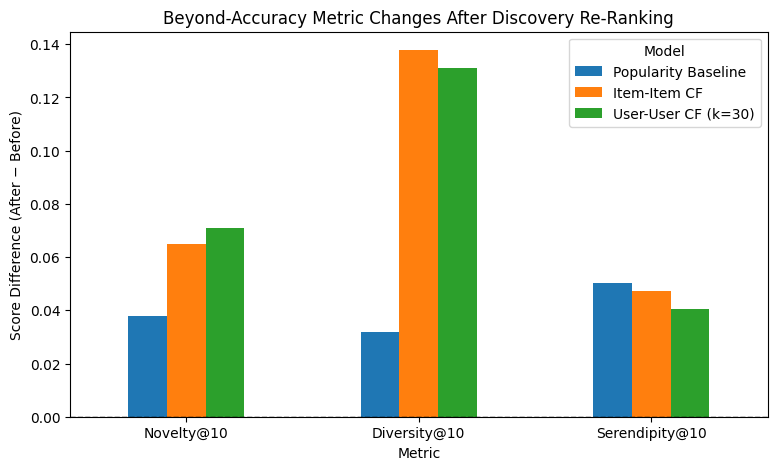

In [83]:
metric_cols = ['novelty_at_10', 'diversity_at_10', 'serendipity_at_10']

plot_data = (
    comparison[comparison['metric'].isin(metric_cols)]
    .pivot(index='metric', columns='model', values='change')
)
plot_data = plot_data[
    [
        'Popularity Baseline',
        'Item-Item CF',
        'User-User CF (k=30)'
    ]
]

plot_data = plot_data.loc[['novelty_at_10', 'diversity_at_10', 'serendipity_at_10']]
plot_data.index = ['Novelty@10', 'Diversity@10', 'Serendipity@10']

plot_data.plot(kind='bar', figsize=(9,5))

plt.title('Beyond-Accuracy Metric Changes After Discovery Re-Ranking')
plt.xlabel('Metric')
plt.ylabel('Score Difference (After − Before)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.show()

## Example Recommendations

To make the results more interpretable, here is an example of a user's recommendations before and after re-ranking. This will show how the re-ranking step changes the actual list, not just the metrics.

- Several artists remain because they were already highly relevant, while others move up or are replaced by artists that achieve a better overall re-ranking score by balancing the original recommendation rank with novelty, diversity, and serendipity.
- As a result, some artists are introduced even if they do not have the highest individual novelty or serendipity score, because they contribute to a more balanced and varied recommendation list.

This demonstrates that the re-ranking step preserves many strong recommendations while creating more opportunities for discovery.

In [86]:
artist_lookup = artists.rename(columns={'id': 'artistId'})[['artistId', 'name']]
artist_name = dict(zip(artist_lookup['artistId'], artist_lookup['name']))


def display_recommendations(user_id, recommender_func, k=10):
    recs = recommender_func(user_id, n=50)[:k]

    return pd.DataFrame({
        'Rank': range(1, len(recs) + 1),
        'Artist': [artist_name.get(item, 'Unknown') for item in recs],
        'Novelty': [round(artist_novelty.get(item, 0), 3) for item in recs],
        'Serendipity': [round(item_serendipity_score(user_id, item), 3) for item in recs]
    })


example_user = eval_users[0]

before = display_recommendations(
    example_user,
    recommend_item_item_cf
)

after = display_recommendations(
    example_user,
    reranked_models['Item-Item CF + Discovery Re-Rank']
)

comparison = before.merge(
    after,
    on='Rank',
    suffixes=(' (Before)', ' (After)')
)

comparison

,Rank,Artist (Before),Novelty (Before),Serendipity (Before),Artist (After),Novelty (After),Serendipity (After)
0,1,Pet Shop Boys,0.864,0.552,Orchestral Manoeuvres in the Dark,0.930,0.611
1,2,Orchestral Manoeuvres in the Dark,0.930,0.611,Pet Shop Boys,0.864,0.552
2,3,The Human League,0.922,0.600,Simple Minds,0.950,0.659
3,4,Erasure,0.924,0.590,Kraftwerk,0.926,0.670
4,5,a-ha,0.840,0.611,The Human League,0.922,0.600
5,6,Eurythmics,0.944,0.605,Erasure,0.924,0.590
6,7,Tears for Fears,0.914,0.623,Eurythmics,0.944,0.605
7,8,Simple Minds,0.950,0.659,a-ha,0.840,0.611
8,9,The Cure,0.637,0.670,U2,0.711,0.781
9,10,Ultravox,0.954,0.629,Tears for Fears,0.914,0.623


## Interpretation of Results

The results basically show the trade-off that often occurs when we optimize recommender systems beyond accuracy. The original recommendation lists prioritized predicted relevance, while the discovery re-ranking step intentionally promoted a more varied, less popularity-driven and more unexpected set of artists.

Although Precision@10, Recall@10, and NDCG@10 decreased slightly after re-ranking, this does not necessarily mean that it is a worse recommender. Actually, it reflects a deliberate shift toward improving novelty, diversity, and serendipity. For a real music streaming service, this trade-off might be worthwhile if it encourages users to discover new artists, listen longer or just report higher satisfaction.

Ultimately, the best recommendation strategy depends on the goals that the platform has. If they want to focus on maximizing short-term prediction accuracy, the original collaborative filtering models would probably be preferable. However, if they are more interested in encouraging long-term discovery and exploration, the discovery re-ranked models would likely provide a better balance between relevance and user experience.

## Online Evaluation Discussion

Offline evaluation is useful because it lets us compare algorithms before showing recommendations to users. However, it cannot fully tell us how users would respond in a real application.

If online evaluation were possible, I would run an A/B test:
- **Control group:** receives the best raw recommender from the offline evaluation.
- **Treatment group:** receives the same recommender with discovery re-ranking.
- **Random assignment:** users are randomly assigned to control or treatment.
- **Fixed interface:** the recommendation layout stays the same so the algorithm is the main difference.
- **Primary online metrics:** click-through rate, artist plays, saves/favorites, skip rate, repeat listening, and session length.
- **User experience metrics:** whether users engage with a wider range of artists and whether they return to the platform later.

I would also monitor guardrail metrics to make sure that the discovery adjustments do not negatively affect the overall user experience. 

For example, if the treatment group shows substantially lower engagement or a much higher skip rate, the re-ranking strategy may be too aggressive. A production A/B test would begin with a small percentage of users and gradually expand only if the new recommendation strategy performs well.

## Additional Experiments

A few additional experiments could improve this project:

1. **Tune the re-ranking weights.** I used fixed novelty, diversity, and serendipity weights, but these could be tested across several values to find a better balance.
2. **Compare more values of K.** I focused on top-10 recommendations, but top-5 or top-20 may tell a different story.
3. **Segment users.** New users and heavy listeners may respond differently to novelty, diversity, and serendipity.
4. **Use online satisfaction data.** A true serendipity metric would need user feedback to know whether an unexpected artist was actually a pleasant surprise.

## Conclusion

- In this project, I used a new Last.fm dataset and compared multiple recommender algorithms for a top-N music recommendation task. Because the dataset contains implicit listening behavior, I evaluated the models using ranking metrics rather than only rating prediction error.
- The project also showed why accuracy alone is not enough. A recommender that only focuses on the safest artists may perform well offline, but it may not create the best user experience. By adding a discovery re-ranking step, I was able to compare how recommendation quality changes when the system is adjusted for novelty, diversity, and serendipity.
- Among the models that I evaluated, Item-Item Collaborative Filtering consistently achieved the strongest overall balance between ranking accuracy and discovery-oriented recommendation quality, both before and after the re-ranking step.

Overall, the main takeaway is that recommender systems require trade-offs. Offline metrics like Precision@10, Recall@10, and NDCG@10 help compare models, but online evaluation would be needed to know whether users actually prefer the more diverse and surprising recommendation experience.

## References

- Gunawardana, A., & Shani, G. (2009). *A Survey of Accuracy Evaluation Metrics of Recommendation Tasks.* Journal of Machine Learning Research.
- Konstan, J. A., & Riedl, J. (2012). *Recommender systems: from algorithms to user experience.* User Modeling and User-Adapted Interaction.
- Salihefendic, A. (2015). *How Hacker News ranking algorithm works.* Medium.
- GroupLens. *HetRec 2011 Last.fm 2K dataset.*
- DATA 612 Meetup 4 materials.